# Haim feedback (2026-07-27)
Suggestion to handle project in 3 phases:
1. Data import/treatment
2. Modelisation
3. Presentation
   
>Ton document laisse cette section ouverte, marquée « à définir », et c’est légitime à ce stade. Je te propose quelques repères, non comme une solution imposée, mais comme une trame à discuter.
> L’application se prête naturellement à une séparation en trois couches : une couche de lecture, qui charge les fichiers d’entrée et les met en mémoire sous une forme exploitable ; une couche de modèle, qui reconstitue la chronologie du jeu, associe à chaque instant une position et les événements actifs ; et une couche de présentation, l’interface Streamlit ou équivalent, qui superpose ces données sur le plan du niveau et les anime au fil de la frise. La frontière la plus utile à tenir est celle entre le modèle temporel, qui est de la logique pure et testable, et l’affichage, qui en est le rendu. Si tu vérifies que ton modèle restitue correctement le parcours indépendamment de tout affichage, le reste devient un travail d’interface.

# MVP Features
1. Export to CSV
2. 

# Environment setup

## Install Pandas
That error means conda isn't installed on your system yet. Here's how to get it set up:
1. Download Miniconda (lightweight conda installer):
2. 
```bash
# For macOS (Apple Silicon / M-series)
curl -O https://repo.anaconda.com/miniconda/Miniconda3-latest-MacOSX-arm64.sh

# For macOS (Intel)
curl -O https://repo.anaconda.com/miniconda/Miniconda3-latest-MacOSX-x86_64.sh
```
2. Run the installer:

```bash
bash Miniconda3-latest-MacOSX-arm64.sh
```
Follow the prompts — say "yes" to the license and "yes" when it asks to initialize conda.

3. Reload your shell:

```bash
source ~/.zshrc
```
4. Verify it works:

```bash
conda --version
```
5. Now run your original command:

```bash
conda install -c conda-forge pandas
```

### Create environment
```bash
# Create an environment for your project
conda create -n myproject python=3.12

# Activate it
conda activate myproject

# Now install packages into that environment
conda install -c conda-forge pandas
```

```bash
conda activate myproject
conda install ipykernel
python -m ipykernel install --user --name myproject --display-name "myproject"
````

After creating and activating your conda environment, you need to make it visible as a kernel in VS Code:

1. Install the kernel package in your environment:

```bash
conda activate myproject
conda install ipykernel
```
2. Register it as a kernel:

```bash
python -m ipykernel install --user --name myproject --display-name "myproject"
```
3. In VS Code, open your notebook, click the kernel picker (top right), and you should see "myproject" in the list. If it doesn't appear immediately, reload the window (Cmd+Shift+P → "Reload Window").

That's it — each conda environment you want to use in notebooks needs ipykernel installed and registered. The --display-name is what shows up in the picker.


## Install Matplotlib
```bash
conda install matplotlib 
```

# Data Import
Original data is in JSON format.
- [ ] Explain why JSON (+)Save objects (-)manually create CSV
- [ ] Use of Numpy

In [ ]:
{
   "saveDateTime": "2026-07-26 20:11:07",
   "playerId": "id_001",
   "playerSaveObjectList": [
      {
         "gametimer": 5.528238773345947,
         "position": {
            "x": 90.0,
            "y": 0.0,
            "z": 60.0
         },
         "rotation": {
            "x": 0.0,
            "y": 46.83423614501953,
            "z": 0.0
         }
      },
      {
         "gametimer": 6.530888080596924,
         "position": {
            "x": 90.0,
            "y": 0.0,
            "z": 60.0
         },
         "rotation": {
            "x": 0.0,
            "y": 107.00001525878906,
            "z": 0.0
         }
      }
   ]
}

## Import JSON file as a dataframe

In [ ]:
# FIRST TRY - discarted
import pandas as pd


FILENAME = "../data/savefile_01_pos_rot.json"

# with open (FILENAME, mode="r") as file:
#    df = pd.DataFrame(file)
df = pd.read_json(FILENAME)

print(df)

           saveDateTime playerId  \
0   2026-07-26 20:11:07   id_001   
1   2026-07-26 20:11:07   id_001   
2   2026-07-26 20:11:07   id_001   
3   2026-07-26 20:11:07   id_001   
4   2026-07-26 20:11:07   id_001   
..                  ...      ...   
61  2026-07-26 20:11:07   id_001   
62  2026-07-26 20:11:07   id_001   
63  2026-07-26 20:11:07   id_001   
64  2026-07-26 20:11:07   id_001   
65  2026-07-26 20:11:07   id_001   

                                 playerSaveObjectList  
0   {'gametimer': 5.528238773345947, 'position': {...  
1   {'gametimer': 6.530888080596924, 'position': {...  
2   {'gametimer': 7.531301021575928, 'position': {...  
3   {'gametimer': 8.531609535217285, 'position': {...  
4   {'gametimer': 9.531744003295898, 'position': {...  
..                                                ...  
61  {'gametimer': 66.77377319335938, 'position': {...  
62  {'gametimer': 67.78170013427734, 'position': {...  
63  {'gametimer': 68.78193664550781, 'position': {...  
64  {'g

In [50]:
import json
import pandas as pd
import datetime as dt

FILENAME = "../data/savefile_01_pos_rot.json"
 
# 1. Load the raw JSON
with open(FILENAME, mode="r") as file:
    json_data = json.load(file)

# 2. Extract top-level metadata
player_id: str = json_data["playerId"]
save_time: dt.datetime = dt.datetime.strptime(json_data["saveDateTime"], "%Y-%m-%d %H:%M:%S")

# 3. Build rows from the list, reshaping position/rotation into tuples
rows = []
for entry in json_data["playerSaveObjectList"]:
    rows.append({
        "time":      entry["gametimer"],
        "position":  (entry["position"]["x"], entry["position"]["y"], entry["position"]["z"]),
        "rotation":  (entry["rotation"]["x"], entry["rotation"]["y"], entry["rotation"]["z"]),
        "playerId":  player_id,
        "saveTime":  save_time,
    })

# 4. Create the DataFrame
df = pd.DataFrame(rows)

print(df.head())
print("-----------")
print(df.dtypes)

       time           position                        rotation playerId  \
0  5.528239  (90.0, 0.0, 60.0)   (0.0, 46.83423614501953, 0.0)   id_001   
1  6.530888  (90.0, 0.0, 60.0)  (0.0, 107.00001525878906, 0.0)   id_001   
2  7.531301  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
3  8.531610  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
4  9.531744  (90.0, 0.0, 60.0)   (0.0, 87.09896087646484, 0.0)   id_001   

             saveTime  
0 2026-07-26 20:11:07  
1 2026-07-26 20:11:07  
2 2026-07-26 20:11:07  
3 2026-07-26 20:11:07  
4 2026-07-26 20:11:07  
-----------
time               float64
position            object
rotation            object
playerId               str
saveTime    datetime64[us]
dtype: object


# Plot the player's position over time

[90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 90.0, 89.79219818115234, 89.01451110839844, 89.1740493774414, 89.1539306640625, 89.23359680175781, 89.23359680175781, 89.23359680175781, 90.29725646972656, 91.54380798339844, 91.98143768310547, 92.99075317382812, 95.3897476196289, 98.26689910888672, 101.28170013427734, 104.1786880493164, 107.03135681152344, 109.98646545410156, 112.87757873535156, 115.71399688720703, 118.56256103515625, 121.56963348388672, 124.58345794677734, 127.58360290527344, 130.60678100585938, 133.60589599609375, 136.61346435546875, 139.43191528320312, 142.15440368652344, 144.55966186523438, 146.43959045410156, 147.8705291748047, 148.36276245117188, 148.79147338867188, 148.83612060546875, 148.86541748046875, 149.2828369140625, 149.43482971191406, 149.58746337890625, 149.61044311523438, 149.67214965820312, 149.6884765625, 149.7047882080078, 149.9098663330078, 150.00125122070312, 150.0737762451172, 150.1464385986328, 150.01397705078125, 149.5387725830078, 148.05519104003906, 146.1

(-15.0, 135.0)

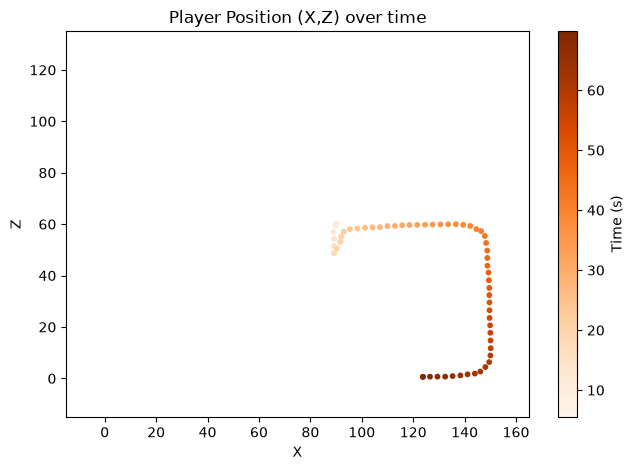

In [87]:
import matplotlib.pyplot as plt

# MAP SIZE
GRID_COLS: int = 6
GRID_ROWS: int = 5
BLOCK_SIZE: int = 30

# The extent is computed — maps pixel corners to world coordinates
map_extent = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

x_list =  [x for (x,y,z) in df["position"]]
z_list =  [z for (x,y,z) in df["position"]]
t_list: list[float] = [_ for _ in df["time"]]

print(x_list)
print(z_list)
print(t_list)

fig, ax = plt.subplots()

scatter = ax.scatter(x_list,z_list, c=t_list, cmap="Oranges", s=10) #  edgecolors="orange", linewidths=0.5
ax.set_title("Player Position (X,Z) over time")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_aspect("equal")

plt.colorbar(scatter, ax=ax, label="Time (s)")
plt.tight_layout()

plt.xlim(map_extent[0],map_extent[1])
plt.ylim(map_extent[2], map_extent[3])

## Overlay the image


(0.0, 150.0)

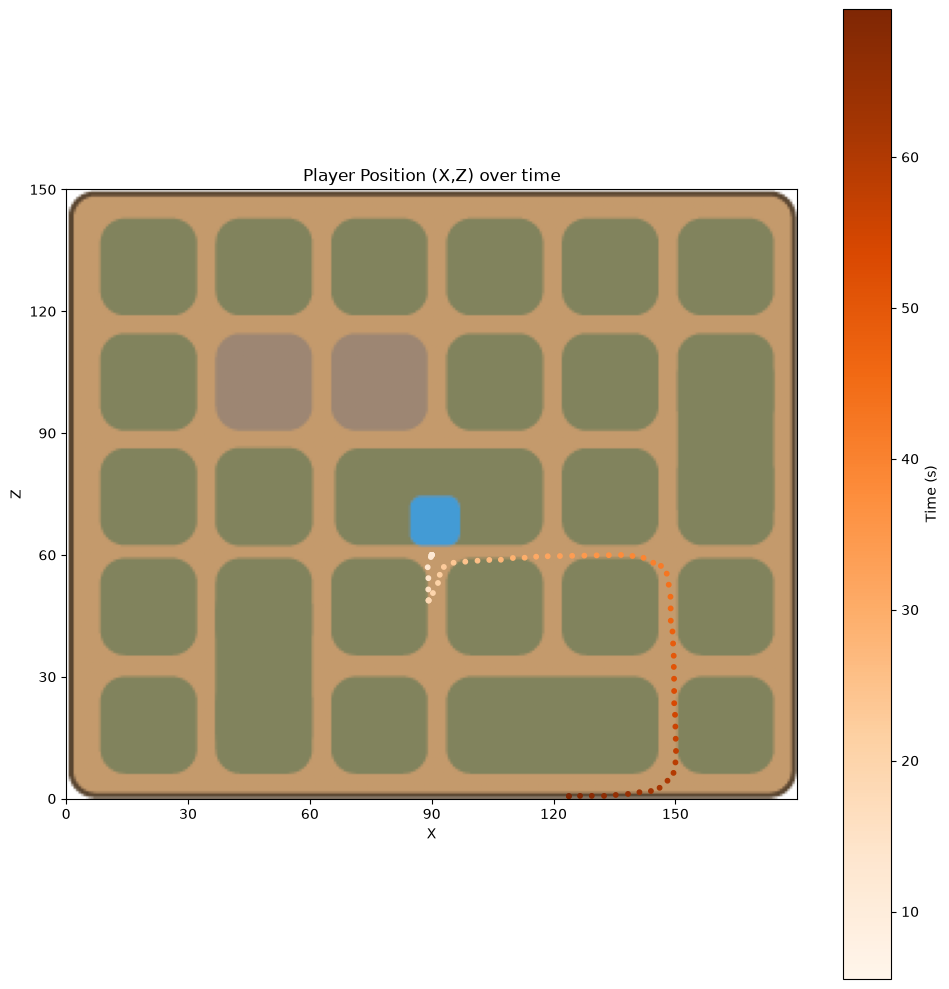

In [94]:
import matplotlib.image as mpimg
import numpy as np

# --- Map config (change per level) ---
MAP_IMAGE = "../images/map_level1.png"

map = mpimg.imread(MAP_IMAGE)

map_x_offset = BLOCK_SIZE / 2
map_z_offset = BLOCK_SIZE / 2

map_coord = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_coord[0] += map_x_offset  # left
map_coord[1] += map_x_offset  # right
map_coord[2] += map_z_offset  # bottom
map_coord[3] += map_z_offset  # top


fig, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10,10))

scatter = ax2.scatter(x_list,z_list, c=t_list, cmap="Oranges", s=10) #  edgecolors="orange", linewidths=0.5

ax2.imshow(map, extent=map_coord, origin="upper", aspect="equal")
ax2.set_title("Player Position (X,Z) over time")
ax2.set_xlabel("X")
ax2.set_ylabel("Z")
ax2.set_aspect("equal")

ticks = np.arange(0,map_coord[1],30)
ax2.set_xticks(ticks)
ax2.set_yticks(ticks)

plt.colorbar(scatter, ax=ax2, label="Time (s)")
plt.tight_layout()


plt.xlim(map_coord[0],map_coord[1])
plt.ylim(map_coord[2], map_coord[3])